In [1]:
from retinotopy import *

Running on GPU :  NVIDIA GeForce RTX 3060 #GPU= 1
---------------------------------------------------------------------------------------------------
On date 2024-05-24, Running learning on host DESKTOP-27VNO0E with device cuda, pytorch==2.2.0+cu121
---------------------------------------------------------------------------------------------------
Welcome on Linux-5.10.16.3-microsoft-standard-WSL2-x86_64-with-glibc2.35
Random seed 1998 has been set.


In [2]:
data_set_type = 'full'
args = Params()
args.root  = f'{DATAROOT}/Imagenet_{data_set_type}' # Directory containing images
args.folders = ['val'] # type of images to use

args.do_saccade = False
args.do_resize = False
args.do_mask = False
args.do_polar = False

image_dataset = image_datasets_transforms(args, shuffle=False, verbose=False)
annotations = get_annotation('csv')

In [3]:
def imshow_heat(img_list, ground_true, title=None, fig_height=5, fig=None, ax = None): #allow to display the input image
    if ax is None:
        fig, ax = plt.subplots(figsize=(fig_height*len(img_list), fig_height))
    images = torchvision.utils.make_grid(img_list)
    """Imshow for Tensor."""
    inp = images.numpy().transpose((1, 2, 0))
    inp = im_std * inp + im_mean
    inp = np.clip(inp, 0, 1)
    ax.imshow(inp)
    ax.imshow(ground_true, alpha=.5)
    ax.set_xticks([])
    ax.set_yticks([])
    if title is not None: plt.title(title)
    plt.tight_layout()
    fig.set_facecolor(color='white')

def imgs_to_np(img_list, im_mean=im_mean, im_std=im_std):
    images = torchvision.utils.make_grid(img_list)
    """Imshow for Tensor."""
    inp = images.numpy().transpose((1, 2, 0))
    inp = im_std * inp + im_mean
    inp = np.clip(inp, 0, 1)
    return(inp)


folding_chair 27972
remote_control 38074
tibetan_mastiff 12226


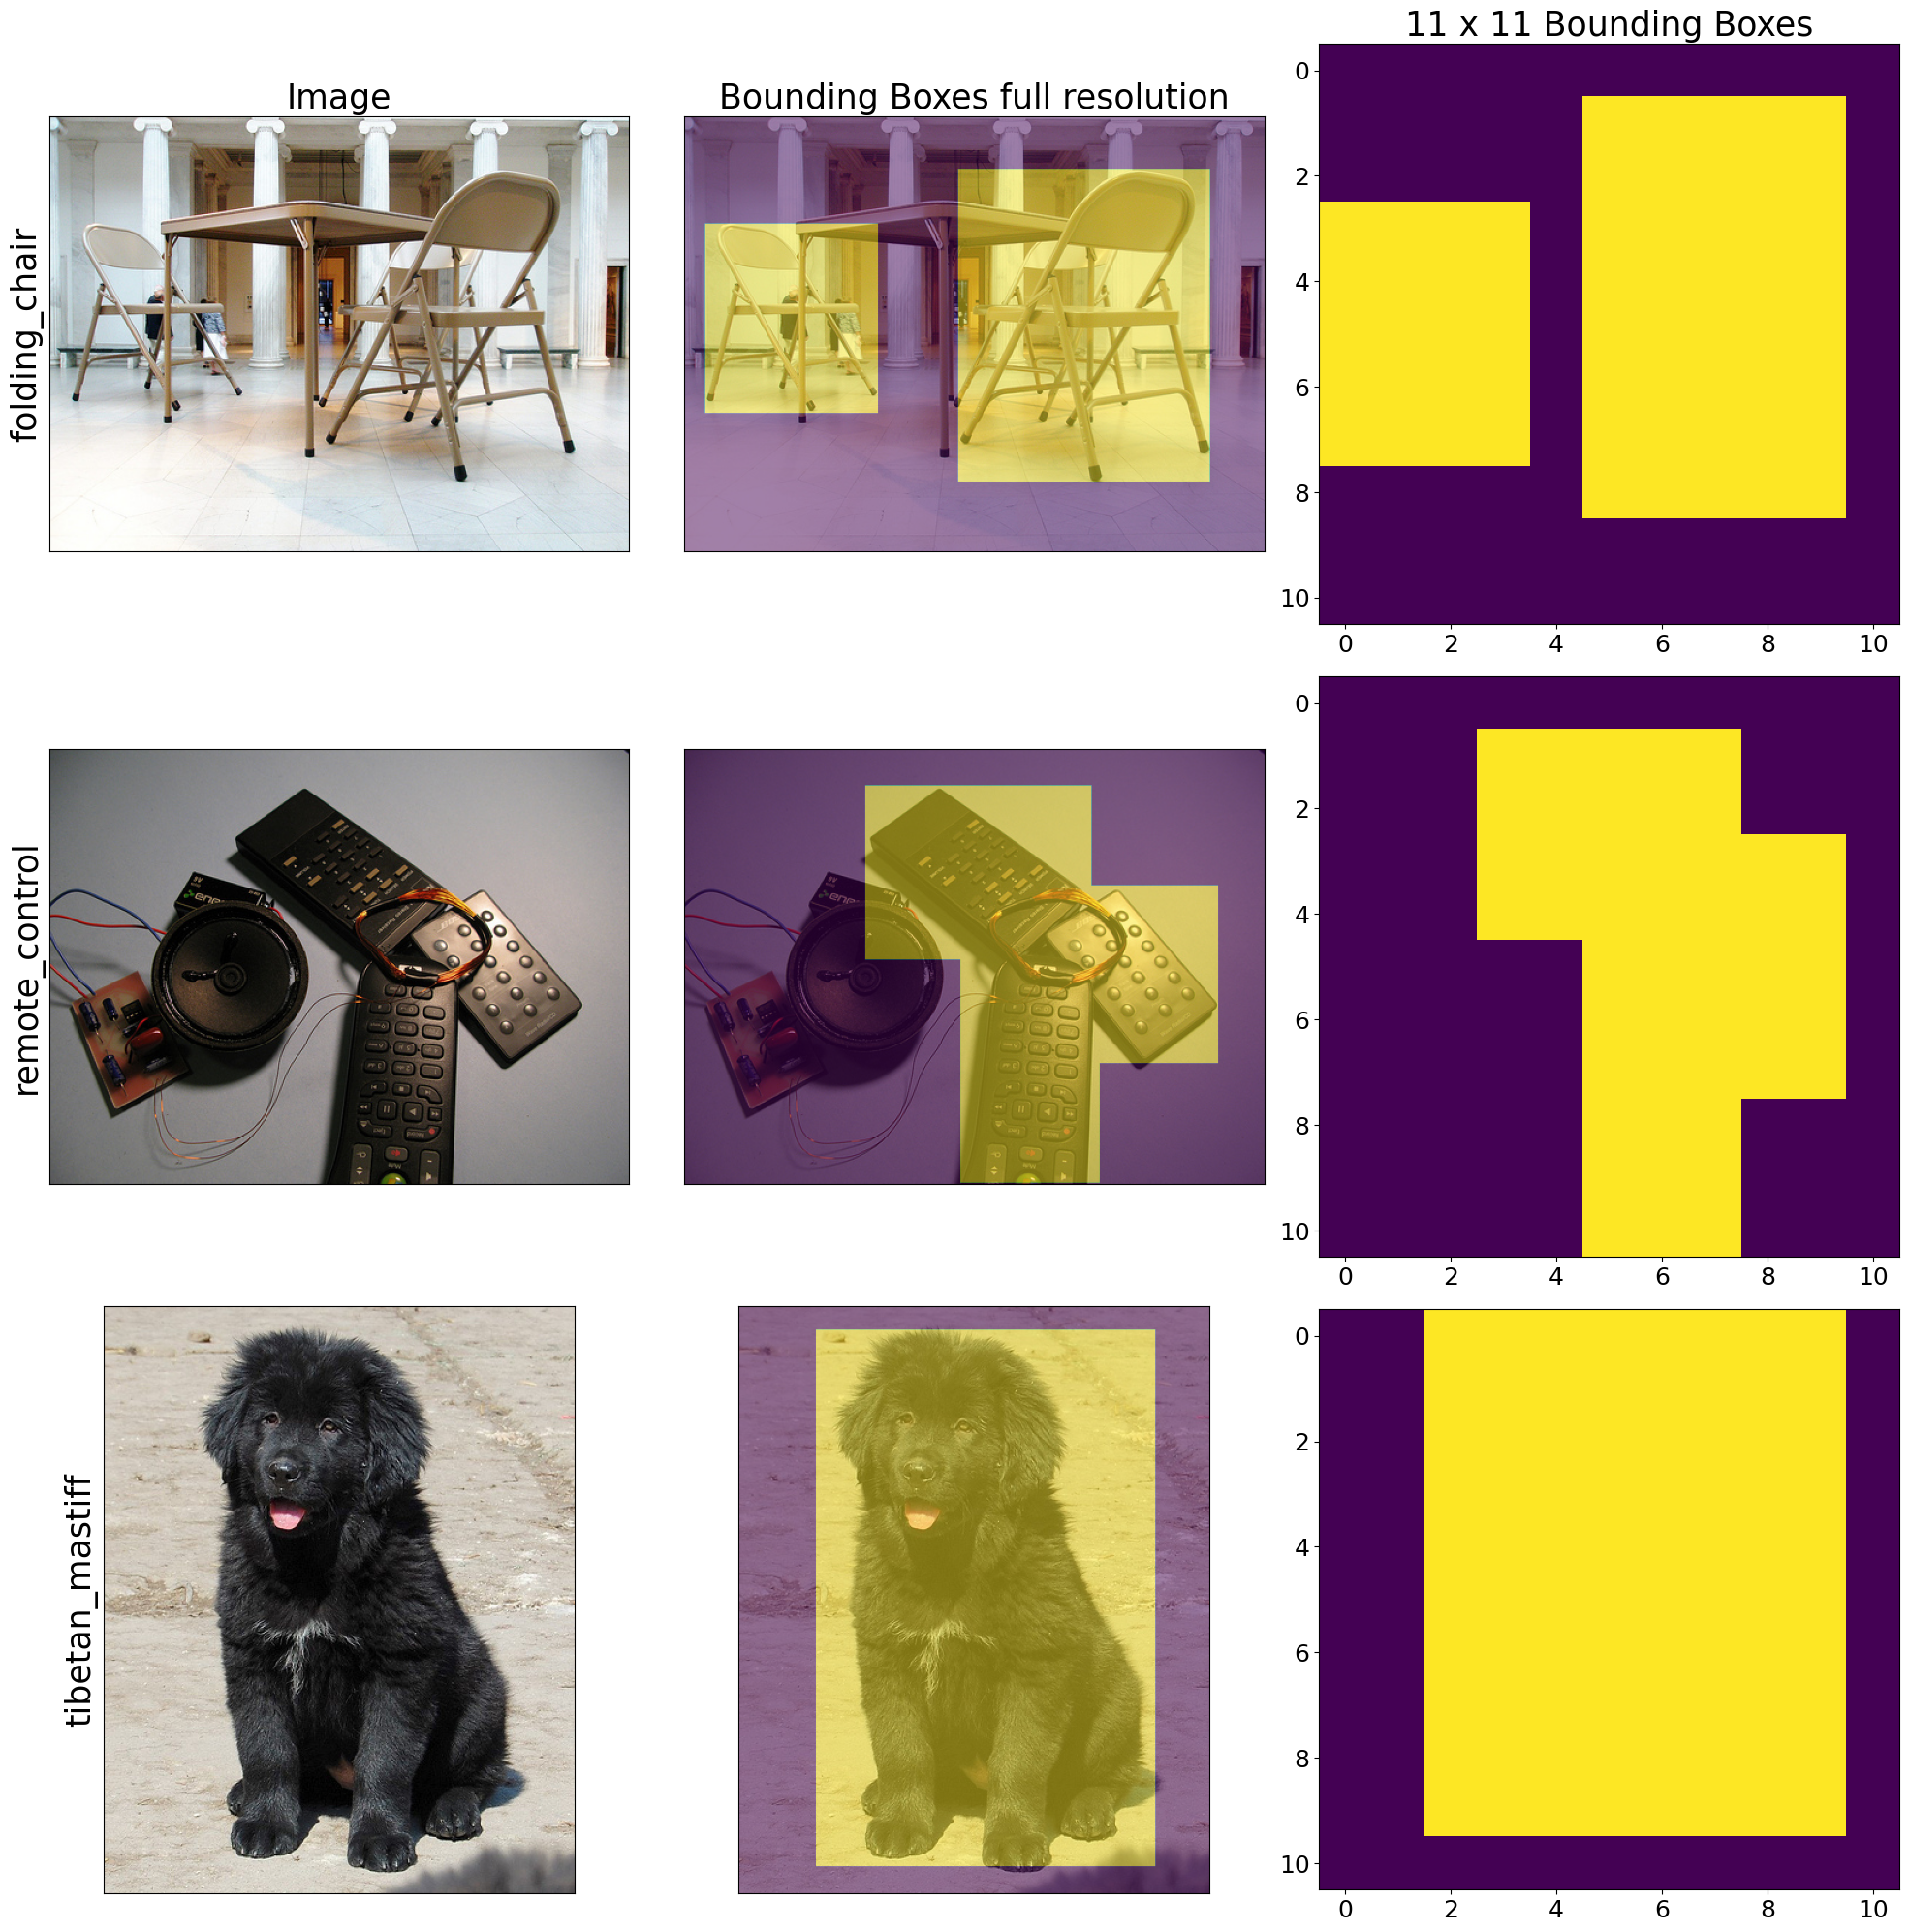

In [4]:
num_image_plot = 3
fig, all_axs = plt.subplots(num_image_plot, 3, figsize=(fig_width, fig_width), squeeze=True)
for i_image, ind in enumerate((np.random.rand(num_image_plot)*50000)):
    ind = int(ind)
    (full_image, true_label) = image_dataset[ind]
    axs = all_axs[i_image] if num_image_plot > 1 else all_axs
    image_name = image_dataset.samples[ind][0].split('/')[-1].split('.')[0]
    args.resolution = (full_image.shape[2], full_image.shape[1])
    
    print(labels[true_label], ind)
    
    ground_true_indices, three_points, ground_true, origin_size = get_ground_true(args, image_name, annotations, 'Imagenet')
    ax = axs[0]

    labels_i_image = labels[true_label]
    ax.set_ylabel(labels_i_image, fontsize=25)
    ax.imshow(imgs_to_np(full_image), origin="upper")
    ax.set_xticks([])
    ax.set_yticks([])

    
    ax = axs[1]
    imshow_heat(full_image, ground_true, fig=fig, ax=ax)

    args = Params()
    ground_true_indices, three_points, ground_true, origin_size = get_ground_true(args, image_name, annotations, 'Imagenet')
    ax = axs[2]

    ax.imshow(ground_true, origin="upper")

    all_axs[0,0].set_title('Image', fontsize=25)
    all_axs[0,1].set_title("Bounding Boxes full resolution", fontsize=25)
    all_axs[0,2].set_title("11 x 11 Bounding Boxes", fontsize=25)



magpie 945


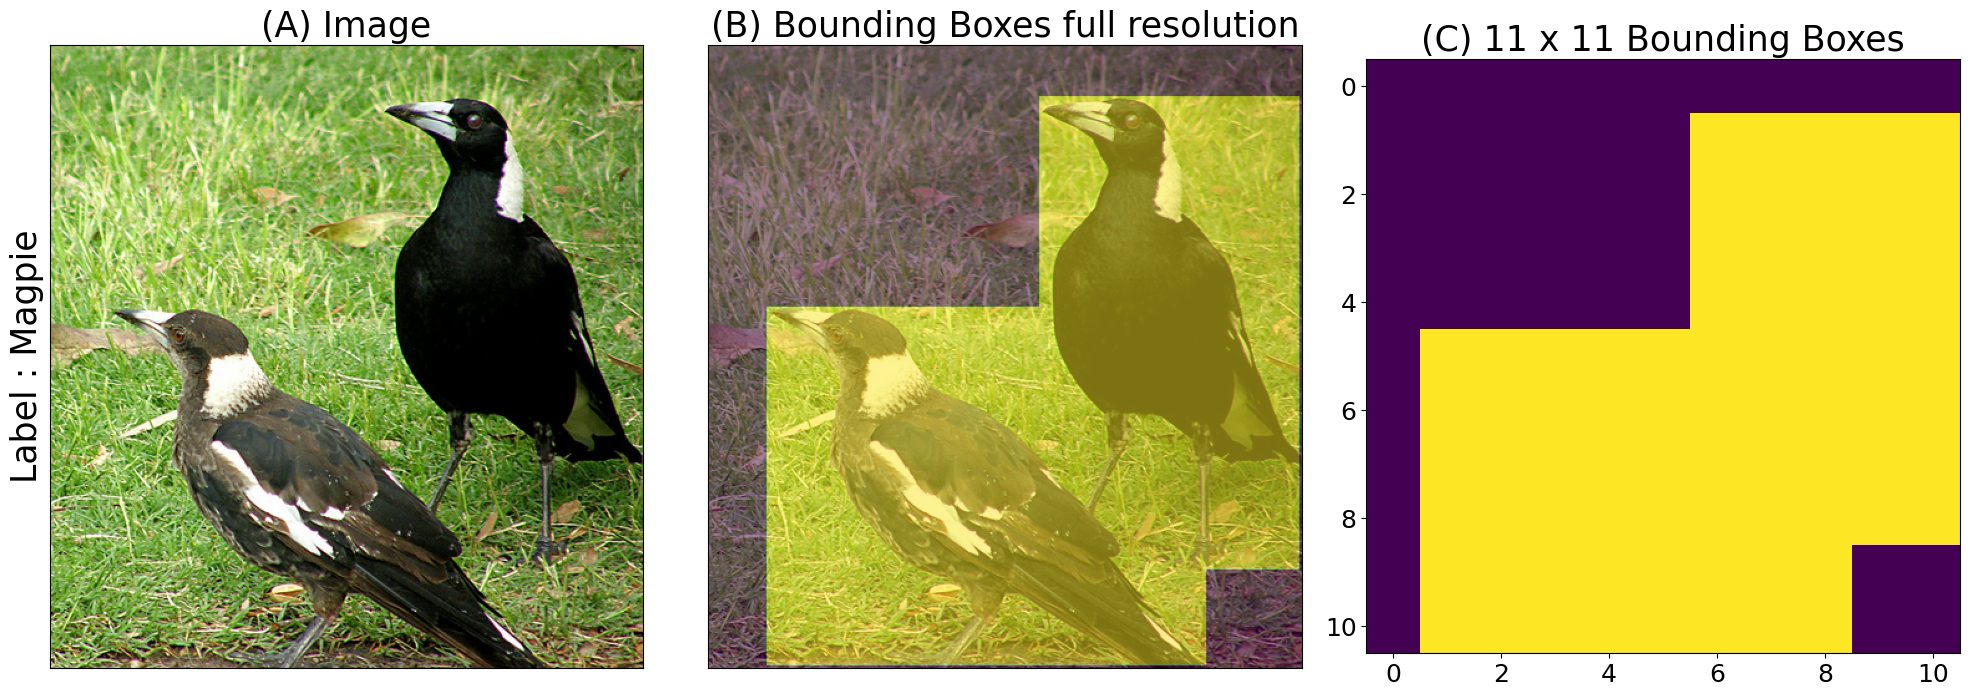

In [5]:
num_image_plot = 1
fig, all_axs = plt.subplots(num_image_plot, 3, figsize=(fig_width, fig_width), squeeze=True)
for i_image, ind in enumerate((np.random.rand(num_image_plot)*50000)):
    ind = int(ind)
    ind = 945
    (full_image, true_label) = image_dataset[ind]
    axs = all_axs[i_image] if num_image_plot > 1 else all_axs
    image_name = image_dataset.samples[ind][0].split('/')[-1].split('.')[0]
    args.resolution = (full_image.shape[2], full_image.shape[1])

    

    print(labels[true_label], ind)
    
    ground_true_indices, three_points, ground_true, origin_size = get_ground_true(args, image_name, annotations, 'Imagenet')
    ax = axs[0]

    labels_i_image = labels[true_label]
    ax.set_ylabel('Label : Magpie', fontsize=25)
    ax.imshow(imgs_to_np(full_image), origin="upper")
    ax.set_xticks([])
    ax.set_yticks([])

    
    ax = axs[1]
    imshow_heat(full_image, ground_true, fig=fig, ax=ax)

    args = Params()
    ground_true_indices, three_points, ground_true, origin_size = get_ground_true(args, image_name, annotations, 'Imagenet')
    ax = axs[2]

    ax.imshow(ground_true, origin="upper")

    all_axs[0].set_title('(A) Image', fontsize=25)
    all_axs[1].set_title("(B) Bounding Boxes full resolution", fontsize=25)
    all_axs[2].set_title("(C) 11 x 11 Bounding Boxes", fontsize=25)


In [6]:
for ext in ['pdf', 'png']:
    fig.savefig(f'figs/fig-imagenet_ground_truth.{ext}',  **opts_savefig)

In [11]:
# The dataset to import images from

data_set_type = 'animal_10k'
args = Params()
args.root = f'{DATAROOT}/{data_set_type}/ap-10k/' # Directory containing images
args.folders = ['animal_data'] # type of images to use

args.do_saccade = False
args.do_resize = False
args.do_mask = False
args.do_polar = False

annotations = get_annotation('animal_10k')
image_dataset = image_datasets_transforms(args, shuffle=False, verbose=False)

4438 000000030995.jpg


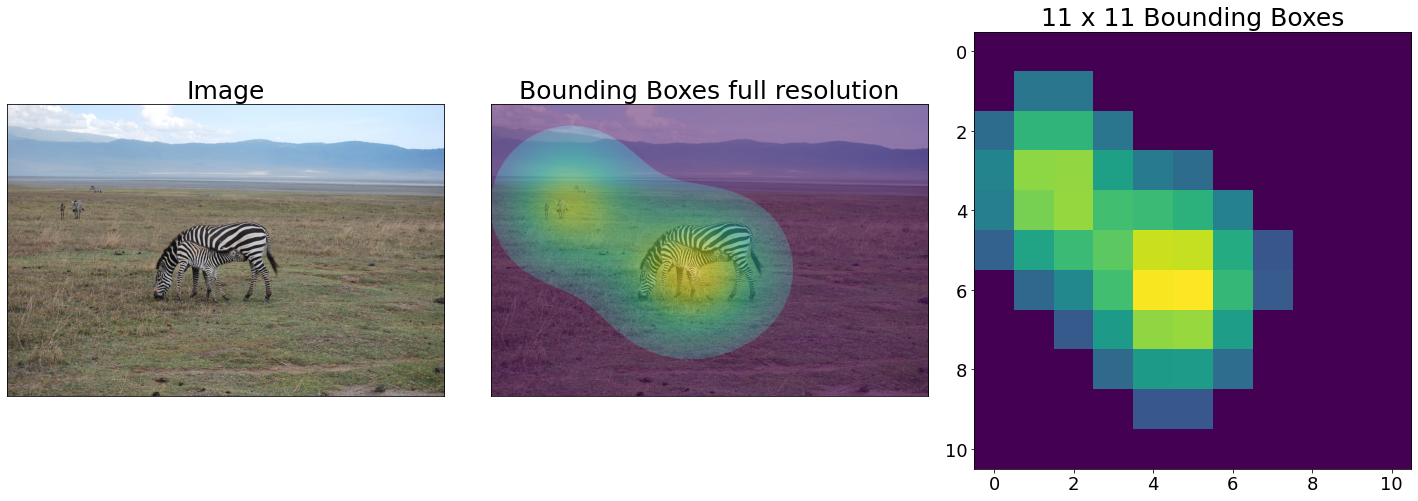

In [12]:
num_image_plot = 1
fig, all_axs = plt.subplots(num_image_plot, 3, figsize=(fig_width, fig_width), squeeze=True)

for i_image, ind in enumerate((np.random.rand(num_image_plot)*10000)):
    ind = int(ind) if num_image_plot > 1 else 4438
    (full_image, true_label) = image_dataset[ind]
    axs = all_axs[i_image] if num_image_plot > 1 else all_axs

    image_name = image_dataset.imgs[ind][0].split('/')[-1]
    
    args.resolution = (full_image.shape[1], full_image.shape[2])
    print(ind, image_name)
    ground_true_indices, three_points, ground_true, origin_size = get_ground_true(args, image_name, annotations, 'Animal10k')

    ax = axs[0]
    ax.imshow(imgs_to_np(full_image), origin="upper")
    ax.set_ylabel('Label : Magpie', fontsize=25)
    ax.set_xticks([])
    ax.set_yticks([])

    
    ax = axs[1]
    imshow_heat(full_image, ground_true, fig=fig, ax=ax)

    args = Params()
    ground_true_indices, three_points, ground_true, origin_size = get_ground_true(args, image_name, annotations, 'Animal10k')
    ax = axs[2]
    ax.imshow(ground_true, origin="upper")
    
    try:
        all_axs[0,0].set_title('(A) Image', fontsize=25)
        all_axs[0,1].set_title("(B) Bounding Boxes full resolution", fontsize=25)
        all_axs[0,2].set_title("(C) 11 x 11 Bounding Boxes", fontsize=25)
    except:
        all_axs[0].set_title('(A) Image', fontsize=25)
        all_axs[1].set_title("(B) Bounding Boxes full resolution", fontsize=25)
        all_axs[2].set_title("(C) 11 x 11 Bounding Boxes", fontsize=25)


In [13]:
for ext in ['pdf', 'png']:
    fig.savefig(f'figs/fig-animal_10k_ground_truth.{ext}',  **opts_savefig)